In [1]:
import numpy as np
import openturns as ot
import openturns.viewer as otw
import otcalibration as otc

In [2]:
import matplotlib
matplotlib.rcParams["text.usetex"]=True
matplotlib.rcParams["font.family"]="serif"
matplotlib.rcParams["font.size"] = "10"

In [3]:
ot.RandomGenerator.SetSeed(0)

In [4]:
size = 10
inputObservations = ot.Sample([[0.5 + i] for i in range(size)])
inputObservations.asPoint()

class=Point name=Unnamed dimension=10 values=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5]

La fonction est :

$$
g(x) = a + \exp(b x), 
$$

pour tout $x\in[0.5,9.5]$.

In [5]:
inVars = ["a", "b", "x"]
formulas = ["a + exp(b * x)"]
g = ot.SymbolicFunction(inVars, formulas)
g

class=SymbolicFunction name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)]

In [6]:
p_ref = [2.8, 0.5]
params = [0, 1]
model = ot.ParametricFunction(g, params, p_ref)
model.setOutputDescription(["y"])
model

class=FunctionImplementation name=Unnamed description=[x,y] evaluationImplementation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2] gradientImplementation=class=ParametricGradient evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2] hessianImplementation=class=ParametricHessian evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2]

In [7]:
sigmaNoiseObservation = 5.0
observationOutputNoise = ot.Normal(0.0, sigmaNoiseObservation)
observationOutputNoise

class=Normal name=Normal dimension=1 mean=class=Point name=Unnamed dimension=1 values=[0] sigma=class=Point name=Unnamed dimension=1 values=[5] correlationMatrix=class=CorrelationMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[1]

In [8]:
if True:
    outputObservations = ot.Sample(size, 1)
    outputObservations[0, 0] = 7.125
    outputObservations[1, 0] = -1.414
    outputObservations[2, 0] = 4.099
    outputObservations[3, 0] = 14.58
    outputObservations[4, 0] = 1.381
    outputObservations[5, 0] = 20.19
    outputObservations[6, 0] = 26.82
    outputObservations[7, 0] = 52.52
    outputObservations[8, 0] = 76.96
    outputObservations[9, 0] = 122.4
if False:
    outputModel = model(inputObservations)
    observationErrorSample = observationOutputNoise.getSample(size)
    outputObservations = outputModel + observationErrorSample
    outputObservations.asPoint()

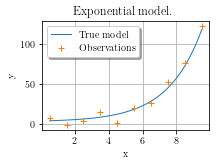

In [9]:
graph = model.draw(0.5, 9.5)
graph.setLegends(["True model"])
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Observations")
graph.add(cloud)
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(2))
graph.setTitle("Exponential model.")
#
view = otw.View(graph, figure_kw = {"figsize": (3.0, 2.0)})
view.save("exp_observations.pdf")

In [10]:
candidate = ot.Point([1.0] * 2)
candidate

class=Point name=Unnamed dimension=2 values=[1,1]

In [11]:
p = candidate.getSize()
parameterCovariance = ot.CovarianceMatrix(p)
for i in range(p):
    parameterCovariance[i, i] = 3.0 + (1.0 + i) * (1.0 + i)
    for j in range(i):
        parameterCovariance[i, j] = 1.0 / (1.0 + i + j)
parameterCovariance

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[4,0.5,0.5,7]

In [12]:
np.linalg.cond(parameterCovariance)

1.8069379146279672

In [13]:
errorCovariance = ot.CovarianceMatrix([[3.0]])
errorCovariance

class=CovarianceMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[3]

In [14]:
np.linalg.cond(errorCovariance)

1.0

In [15]:
algo = ot.GaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
    "SVD",
)
algo.run()
calibrationResult = algo.getResult()

## Analysis of the results

The `getParameterMAP` method returns the maximum of the posterior distribution of $\theta$.

In [16]:
thetaStar = calibrationResult.getParameterMAP()
thetaStar

class=Point name=Unnamed dimension=2 values=[-100.381,0.895329]

In [17]:
thetaPosterior = calibrationResult.getParameterPosterior()

In [18]:
# See Ticket 1106 on github
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)
thetaPosterior.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]

class=Interval name=Unnamed dimension=2 lower bound=class=Point name=Unnamed dimension=2 values=[-101.679,0.895297] upper bound=class=Point name=Unnamed dimension=2 values=[-99.0827,0.89536] finite lower bound=[1,1] finite upper bound=[1,1]

In [19]:
covarianceThetaStar = thetaPosterior.getCovariance()
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.341318,-3.56257e-06,-3.56257e-06,2.03318e-10]

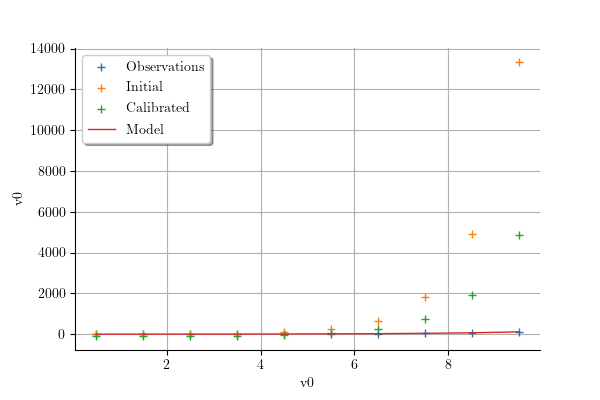

In [20]:
grid = calibrationResult.drawObservationsVsInputs()
grid.setLegendPosition("topleft")
graph = grid.getGraph(0, 0)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Model"])
graph.add(curve)
graph.setColors(ot.Drawable_BuildDefaultPalette(4))
grid.setGraph(0, 0, graph)
grid

## Calculs génériques

In [21]:
parameterDimension = candidate.getDimension()

In [22]:
model.setParameter(candidate)
modelObservations = model(inputObservations)
modelObservations[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=1 description=[y0] data=[[2.64872],[5.48169],[13.1825],[34.1155],[91.0171]]

In [23]:
outputDimension = modelObservations.getDimension()
outputDimension

1

In [24]:
gradientObservations = otc.computeJacobianParameterMatrix(model, inputObservations)
gradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=2 values=[1,1,1,1,1,1,1,1,1,1,0.824361,6.72253,30.4562,115.904,405.077,1345.81,4323.42,13560.3,41775.5,126917]

In [25]:
np.log10(np.linalg.cond(gradientObservations))

4.675901757161763

In [26]:
residuals = outputObservations - modelObservations
# Stack the residuals by observation,
#   deltay = [residuals[i,0],residuals[i,1],...,residuals[i,outputDimension]]
deltay = ot.Point(size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        deltay[i * outputDimension + j] = residuals[i, j]
deltay

class=Point name=Unnamed dimension=10 values=[4.47628,-6.89569,-9.08349,-19.5355,-89.6361,-225.502,-639.322,-1756.52,-4838.81,-13238.3]

In [27]:
observationDimension = errorCovariance.getDimension()
observationDimension

1

In [28]:
R = otc.computeGlobalObservationsCovarianceMatrixFromLocalCovariance(deltay.getSize(), errorCovariance)
R

class=CovarianceMatrix dimension=10 implementation=class=MatrixImplementation name=Unnamed rows=10 columns=10 values=[3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3]

## Par résolution d'un problème de moindres carrés linéaires

Calcule le facteur de Cholesky $L_B$ de $B$ tel que : 
$$
B = L_B L_B^T
$$
où $L_B$ est une matrice triangulaire inférieure.

In [29]:
B = ot.CovarianceMatrix(parameterCovariance)
LB = B.computeCholesky()
LB

class=TriangularMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[2,0.25,0,2.63391]

Calcule le facteur de Cholesky $L_R$ de $R$ tel que : 
$$
R = L_R L_R^T
$$
où $L_R$ est une matrice triangulaire inférieure.

In [30]:
LR = R.computeCholesky()
LR[0:5, :]

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=5 columns=10 values=[1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

Calcule $L_B^{-1}$, première partie de la matrice de conception étendue.

In [31]:
ILB = ot.IdentityMatrix(parameterDimension)
invLB = LB.solveLinearSystem(ILB)
invLB

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.5,-0.0474579,0,0.379663]

Calcule $L_R^{-1}J$, seconde partie de la matrice de conception étendue.

In [32]:
invLRJ = LR.solveLinearSystem(gradientObservations)
invLRJ

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=2 values=[0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.475945,3.88126,17.5839,66.9173,233.871,777.001,2496.13,7829.05,24119.1,73275.8]

Crée $\bar{A}$, la matrice de conception étendue du problème de moindres carrés linéaires.

In [33]:
Abar = ot.Matrix(parameterDimension + size * outputDimension, parameterDimension)
Abar[0:parameterDimension, 0:parameterDimension] = invLB
for i in range(size):
    for j in range(outputDimension):
        for k in range(parameterDimension):
            Abar[i * outputDimension + j + parameterDimension, k] = -invLRJ[
                i * outputDimension + j, k
            ]
Abar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=12 columns=2 values=[0.5,-0.0474579,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,0,0.379663,-0.475945,-3.88126,-17.5839,-66.9173,-233.871,-777.001,-2496.13,-7829.05,-24119.1,-73275.8]

In [34]:
np.log10(np.linalg.cond(Abar))

4.656351462962514

Calcule $L_R^{-1} (y - H(\mu))$, second membre du résidu étendu.

In [35]:
invLRz = LR.solveLinearSystem(deltay)
invLRz

class=Point name=Unnamed dimension=10 values=[2.58438,-3.98123,-5.24436,-11.2788,-51.7514,-130.194,-369.113,-1014.13,-2793.69,-7643.15]

Créée $\bar{y}$ le second membre du problème de moindres carrés linéaires étendu.

In [36]:
ybar = ot.Point(parameterDimension + size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        ybar[i * outputDimension + j + parameterDimension] = -invLRz[
            i * outputDimension + j
        ]
ybar

class=Point name=Unnamed dimension=12 values=[0,0,-2.58438,3.98123,5.24436,11.2788,51.7514,130.194,369.113,1014.13,2793.69,7643.15]

In [37]:
method = ot.SVDMethod(Abar)
method

class=SVDMethod

In [38]:
deltaTheta = method.solve(ybar)
deltaTheta

class=Point name=Unnamed dimension=2 values=[-101.381,-0.104671]

In [39]:
thetaStarLLSQ = candidate + deltaTheta
thetaStarLLSQ

class=Point name=Unnamed dimension=2 values=[-100.381,0.895329]

In [40]:
covarianceThetaLLSQ = method.getGramInverse()
covarianceThetaLLSQ

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.341318,-3.56257e-06,-3.56257e-06,2.03318e-10]

In [41]:
np.log10(np.linalg.cond(covarianceThetaLLSQ))

9.312702925925027

In [42]:
disttheta = ot.Normal(thetaStarLLSQ, covarianceThetaLLSQ)

In [43]:
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)
disttheta.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]

class=Interval name=Unnamed dimension=2 lower bound=class=Point name=Unnamed dimension=2 values=[-101.678,0.895297] upper bound=class=Point name=Unnamed dimension=2 values=[-99.0843,0.89536] finite lower bound=[1,1] finite upper bound=[1,1]

## Calibration based on Kalman matrix

Compute inverses of B and R.

In [44]:
B = ot.CovarianceMatrix(parameterCovariance)
IB = ot.IdentityMatrix(parameterDimension)
invB = B.solveLinearSystem(IB)

In [45]:
IR = ot.IdentityMatrix(R.getNbRows())
invR = R.solveLinearSystem(IR)

Calcule $A^{-1} = B^{-1} + J^T R^{-1} J = B^{-1} + J^T (J^T R^{-1})^T$.

Soit $C =J^T R^{-1}$. 

Cela implique $A^{-1} = B^{-1} + J^T C^T$.

In [46]:
C = gradientObservations.transpose() * invR

In [47]:
invA = invB + C * gradientObservations
invA

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[3.58559,62827.1,62827.1,6.01926e+09]

In [48]:
np.log10(np.linalg.cond(invA))

9.312702925927741

In [49]:
invB

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.252252,-0.018018,-0.018018,0.144144]

In [50]:
C * gradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[3.33333,62827.2,62827.2,6.01926e+09]

Calcule $K = A J^T R^{-1}$ en tant que solution de l'équation matricielle $A^{-1}K = C$.

In [51]:
K = invA.solveLinearSystem(C)
K

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=10 values=[4.76499e-16,4.56518e-11,3.88573e-15,3.7228e-10,1.76042e-14,1.6866e-09,6.69944e-14,6.41851e-09,2.34141e-13,2.24323e-08,7.77897e-13,7.45277e-08,2.499e-12,2.39421e-07,7.83807e-12,7.5094e-07,2.41469e-11,2.31344e-06,7.33602e-11,7.0284e-06]

In [52]:
np.log10(np.linalg.cond(K))

20.876665969179097

Calcule $\hat{\theta} = \mu  + K (y - H(\mu ))$.

In [53]:
thetaStarKalman = candidate + K * deltay
thetaStarKalman

class=Point name=Unnamed dimension=2 values=[0.999999,0.89427]

In [54]:
L = IB - K * gradientObservations

In [55]:
covarianceThetaStarKalman = K * R * K.transpose() + L * B * L.transpose()
covarianceThetaStarKalman

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[3.99999,-4.17506e-05,-4.17506e-05,6.01913e-10]

In [56]:
np.log10(np.linalg.cond(covarianceThetaStarKalman))

10.381602126541118

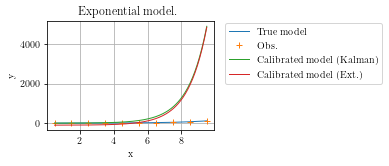

In [57]:
# 1. True model
model.setParameter(p_ref)
graph = model.draw(0.5, 9.5)
graph.setLegends(["True model"])
# 2. Obs
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Obs.")
graph.add(cloud)
# 3. Calibrated model
model.setParameter(thetaStarKalman)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Calibrated model (Kalman)"])
graph.add(curve)
# 4.
model.setParameter(thetaStar)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Calibrated model (Ext.)"])
graph.add(curve)
#
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(4))
# Prepare figure
graph.setTitle("Exponential model.")
legends = graph.getLegends()
graph.setLegendPosition("")
view = otw.View(graph, figure_kw = {"figsize": (3.0, 2.0)})
figure = view.getFigure()
figure.legend(legends, bbox_to_anchor=(1.7, 0.9))
figure.savefig("exp_fit.pdf")

## Vérification de la fonction coût

L'objectif est de vérifier laquelle des deux solutions minimise la fonction coût.

Avant calage.

In [58]:
otc.gaussianCalibrationCostFunction(
    candidate,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[33703481.47895029, 0.0, 33703481.47895029]

Calage par la matrice de Kalman.

In [59]:
thetaStarKalman

class=Point name=Unnamed dimension=2 values=[0.999999,0.89427]

In [60]:
otc.gaussianCalibrationCostFunction(
    thetaStarKalman,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[59545.398024601214, 0.0008056740977841813, 59545.397218927115]

Calage par décomposition de Cholesky.

In [61]:
thetaStarLLSQ

class=Point name=Unnamed dimension=2 values=[-100.381,0.895329]

In [62]:
otc.gaussianCalibrationCostFunction(
    thetaStarLLSQ,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[44488.89833094724, 1296.149042188686, 43192.749288758554]

## Validation

In [63]:
def computeGaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
):
    """Use GaussianLinearCalibration"""
    algo = ot.GaussianLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    thetaStar = calibrationResult.getParameterMAP()
    thetaPosterior = calibrationResult.getParameterPosterior()
    covarianceThetaStar = thetaPosterior.getCovariance()
    return thetaStar, covarianceThetaStar

## GaussianLinearCalibrationCompute

In [64]:
thetaStar, covarianceThetaStar = computeGaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)

In [65]:
thetaStar

class=Point name=Unnamed dimension=2 values=[-100.381,0.895329]

In [66]:
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.341318,-3.56257e-06,-3.56257e-06,2.03318e-10]

## Kalman

In [67]:
thetaStar, covarianceThetaStar = otc.gaussianLinearCalibrationFromKalman(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

class=Point name=Unnamed dimension=2 values=[0.999999,0.89427]

In [68]:
covarianceThetaStar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[3.99999,-4.17506e-05,-4.17506e-05,6.01913e-10]

## From the extended linear least squares

In [69]:
thetaStar, covarianceThetaStar = otc.gaussianLinearCalibrationFromCholesky(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

class=Point name=Unnamed dimension=2 values=[-100.381,0.895329]

In [70]:
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.341318,-3.56257e-06,-3.56257e-06,2.03318e-10]